# 경로 설정하기(1. 마운트 진행하기, 2. 경로 접근하기)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
cd /content/drive/MyDrive/Colab/retinanet/keras_retinanet/bin/

/content/drive/MyDrive/Colab/retinanet/keras_retinanet/bin


# Retina Net 및 데이터 사용에 필요한 라이브러리 설치

In [3]:
!pip install keras-resnet
!pip install keras-retinanet
!pip install pydicom
!pip install read-roi

  Preparing metadata (setup.py) ... done
  Created wheel for keras-resnet: filename=keras_resnet-0.2.0-py2.py3-none-any.whl size=20456 sha256=fc70af25bae1676af5c78fdb78bbacb8488f66fbf0282859603fca661c46d28c
  Stored in directory: /root/.cache/pip/wheels/16/af/88/a668b279c5eadbe55dcaf6207f09059135166cefb09088bacc
Successfully built keras-resnet
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.4/71.4 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for keras-retinanet: filename=keras_retinanet-1.0.0-cp310-cp310-linux_x86_64.whl size=203914 sha256=5a48267f786c80a4c0875da2bdd43114ed5592b21e5a4c753e461cdb0049acc6
  Stored in directory: /root/.cache/pip/wheels/42/ee/d4/b54905a92241002b36db880e88b902ebcb015ce5ae311a16da
Successfully built keras-retinanet
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 13.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for read-roi: filename=read_roi-1.6.0-py2.py3-none-any.whl size=8017 sha25

# 모듈 불러오기

In [4]:
from keras_retinanet import models
from keras_retinanet.utils.image import read_image_bgr, preprocess_image, resize_image
from keras_retinanet.utils.visualization import draw_box, draw_caption
from keras_retinanet.utils.colors import label_color

from keras_retinanet.models import load_model
from keras_retinanet.utils.colors import label_color
import os
import pydicom
import cv2
import keras
import pandas as pd
import numpy as np
import tensorflow as tf
from PIL import Image
from tensorflow.keras.utils import get_file
import os, glob
import matplotlib.pylab as plt
from read_roi import read_roi_file

# 데이터 불러오기
이미지 데이터를 불러옵니다.
glob.glob 함수를 이용해 경로에 있는 파일들을 검색할 수 있습니다.

In [5]:
path = '../../../data/sample_img_eye/'
file_list = glob.glob(path+'*.jpg')

In [6]:
print("image count = ", len(file_list))

image count =  170


# 경로 설정
이미지와 레이블이 합쳐진 영상을 저장하는 경로를 설정합니다.

In [7]:
save_check_data = path+'check_data/'
print(save_check_data)

../../../data/sample_img_eye/check_data/


In [8]:
blue = (255,0,0)

# RetinaNet에 사용하는 데이터의 txt로 생성
1. 영상 이미지에 해당하는 roi file을 불러와 박스 좌표를 생성하여
file 경로와 (x1,y1,x2,y2), class 명으로 작성 후 파일명.txt으로 생성합니다.
 file_total.writelines('../data/'+'name_'+str(i)+'.jpg'+","+str(x1)+","+str(y1)+","+str(x2)+","+str(y2)+",tool(1)\n")
2. ROI와 좌표가 정확하게 생성되었는 지 확인하기 위해 영상에 박스를 표시하여 시각적인 확인을 위해 저장을 합니다.

In [9]:
for i in range(len(file_list)):
  name_in = file_list[i].split('/')[-1].split('.')[0]
  print(file_list[i])
  #txt 파일 저장
  if os.path.exists(file_list[i].split('.jpg')[0]+'.txt'):
    print("file exists")
    os.remove(file_list[i].split('.jpg')[0]+'.txt')
  file_total = open(file_list[i].split('.jpg')[0]+'.txt',"a+")

  img = cv2.imread(file_list[i])
  rois = read_roi_file(file_list[i].split('.jpg')[0]+'.roi')

  # ROI 정보
  print(rois)
  left = rois[name_in]['left']
  top = rois[name_in]['top']
  width = rois[name_in]['width']
  height = rois[name_in]['height']

  # box roi (x1,y1) / (x2,y2)
  x1 = left
  y1 = top
  x2 = left+width
  y2 = top+height

  file_total.writelines('../../data/sample_img_eye/'+'name_'+str(i)+'.jpg'+","+str(x1)+","+str(y1)+","+str(x2)+","+str(y2)+",tool(1)\n")
  img_check = cv2.rectangle(img, (int(x1),int(y1)), (int(x2),int(y2)) ,blue,3)#img,(int(num[0]),int(num[1])),(int(num[2]),int(num[3])),blue,3)
  file_total.close()
  cv2.imwrite(save_check_data+name_in+'.jpg',img_check)

../../../data/sample_img_eye/name_1.jpg
{'name_1': {'type': 'oval', 'left': 278, 'top': -8, 'width': 973, 'height': 967, 'name': 'name_1', 'position': 0}}
../../../data/sample_img_eye/name_2.jpg
{'name_2': {'type': 'oval', 'left': 433, 'top': 37, 'width': 887, 'height': 904, 'name': 'name_2', 'position': 0}}
../../../data/sample_img_eye/name_0.jpg
{'name_0': {'type': 'oval', 'left': 291, 'top': -12, 'width': 967, 'height': 996, 'name': 'name_0', 'position': 0}}
../../../data/sample_img_eye/name_3.jpg
{'name_3': {'type': 'oval', 'left': 422, 'top': 50, 'width': 898, 'height': 856, 'name': 'name_3', 'position': 0}}
../../../data/sample_img_eye/name_4.jpg
{'name_4': {'type': 'oval', 'left': 503, 'top': 101, 'width': 844, 'height': 733, 'name': 'name_4', 'position': 0}}
../../../data/sample_img_eye/name_26.jpg
{'name_26': {'type': 'oval', 'left': 479, 'top': 206, 'width': 760, 'height': 715, 'name': 'name_26', 'position': 0}}
../../../data/sample_img_eye/name_17.jpg
{'name_17': {'type': 'o

# ROI 확인
좌표 계산 후 박스로 표시한 영상을 불러와 확인합니다.

In [10]:
check_img_list = glob.glob(save_check_data+'*.jpg')

(-0.5, 1919.5, 1079.5, -0.5)

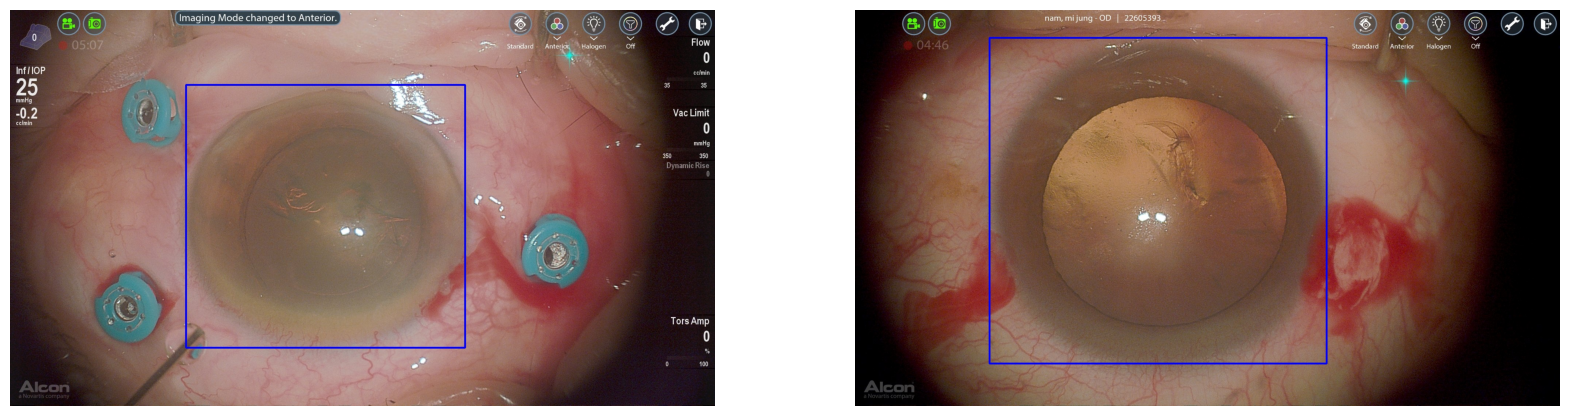

In [11]:
i = 5
img_1 = cv2.imread(check_img_list[i])
img_2 = cv2.imread(check_img_list[i+5])
img_1 = cv2.cvtColor(img_1,cv2.COLOR_BGR2RGB)
img_2 = cv2.cvtColor(img_2,cv2.COLOR_BGR2RGB)

plt.figure(figsize=(20, 20))
plt.subplot(1,2,1)
plt.imshow(img_1)
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(img_2)
plt.axis('off')

# 학습용 / 평가용 데이터의 구성

In [12]:
txt_list = glob.glob(path+'*.txt')

In [13]:
txt_list

['../../../data/sample_img_eye/name_1.txt',
 '../../../data/sample_img_eye/name_2.txt',
 '../../../data/sample_img_eye/name_0.txt',
 '../../../data/sample_img_eye/name_3.txt',
 '../../../data/sample_img_eye/name_4.txt',
 '../../../data/sample_img_eye/name_26.txt',
 '../../../data/sample_img_eye/name_17.txt',
 '../../../data/sample_img_eye/name_10.txt',
 '../../../data/sample_img_eye/name_13.txt',
 '../../../data/sample_img_eye/name_7.txt',
 '../../../data/sample_img_eye/name_8.txt',
 '../../../data/sample_img_eye/name_16.txt',
 '../../../data/sample_img_eye/name_21.txt',
 '../../../data/sample_img_eye/name_11.txt',
 '../../../data/sample_img_eye/name_19.txt',
 '../../../data/sample_img_eye/name_27.txt',
 '../../../data/sample_img_eye/name_6.txt',
 '../../../data/sample_img_eye/name_24.txt',
 '../../../data/sample_img_eye/name_15.txt',
 '../../../data/sample_img_eye/name_23.txt',
 '../../../data/sample_img_eye/name_18.txt',
 '../../../data/sample_img_eye/name_9.txt',
 '../../../data/sam

In [14]:
train_split = int(len(txt_list)/10 * 8)

In [15]:
pwd

'/content/drive/MyDrive/Colab/retinanet/keras_retinanet/bin'

# 학습용 / 평가용 txt 파일 생성
기존에 있던 파일들을 제거 후 위에서 8:2의 비율로 train set / test set으로 나눈 뒤 train.txt 와 test.txt로 생성합니다.

In [16]:
if os.path.exists('../../annotations/train.txt'):
    print("file exists")
    os.remove('../../annotations/train.txt')
file_train = open('../../annotations/train.txt',"a+")

if os.path.exists('../../annotations/test.txt'):
    print("file exists")
    os.remove('../../annotations/test.txt')

file_test = open('../../annotations/test.txt',"a+")

In [17]:
train_split

136

In [18]:
train_count = 0
test_count = 0
for i in range(len(txt_list)):
  content = list()
  with open(txt_list[i], mode="r") as file:
      content = list()

      while True:
          sentence = file.readline()

          if sentence:
              content.append(sentence)
          else:
              break
  for j in range(len(content)):
    print(content[j])
    if i < train_split:
      train_count+=1
      file_train.writelines(content[j])
    else :
      test_count+=1
      file_test.writelines(content[j])
print(train_count,test_count)

../../data/sample_img_eye/name_0.jpg,278,-8,1251,959,tool(1)

../../data/sample_img_eye/name_1.jpg,433,37,1320,941,tool(1)

../../data/sample_img_eye/name_2.jpg,291,-12,1258,984,tool(1)

../../data/sample_img_eye/name_3.jpg,422,50,1320,906,tool(1)

../../data/sample_img_eye/name_4.jpg,503,101,1347,834,tool(1)

../../data/sample_img_eye/name_5.jpg,479,206,1239,921,tool(1)

../../data/sample_img_eye/name_6.jpg,235,101,1170,970,tool(1)

../../data/sample_img_eye/name_7.jpg,560,106,1400,919,tool(1)

../../data/sample_img_eye/name_8.jpg,333,130,1314,1063,tool(1)

../../data/sample_img_eye/name_9.jpg,475,56,1345,869,tool(1)

../../data/sample_img_eye/name_10.jpg,366,78,1284,964,tool(1)

../../data/sample_img_eye/name_11.jpg,215,93,1163,959,tool(1)

../../data/sample_img_eye/name_12.jpg,580,178,1382,1020,tool(1)

../../data/sample_img_eye/name_13.jpg,590,105,1386,914,tool(1)

../../data/sample_img_eye/name_14.jpg,628,90,1490,929,tool(1)

../../data/sample_img_eye/name_15.jpg,481,216,1221,918,

In [19]:
train_count

136

In [20]:
test_count

34

In [21]:
file_train.close()
file_test.close()

# 학습 진행하기
Retina Net은 아래와 같은 구조로 설계된 네트워크 입니다.

ResNet-FPN을 backnone으로 하여 2개의 sub-network를 사용하는 신경망이며 첫 번째 sub-network는 object classification을 수행하며, 다른 sub-network는 bounding box regression을 수행합니다.


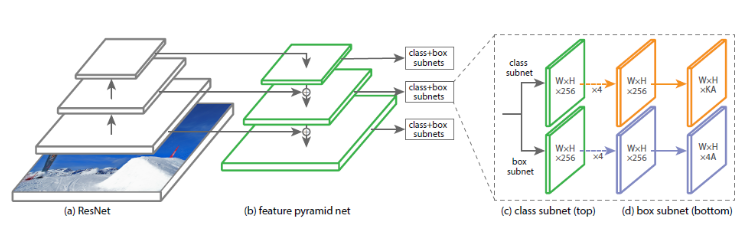

Retinanet은 keras_retinanet/bin/ 에 존재하는 train.py를 통해서 학습을 진행합니다.
제공하는 Retinanet의 train.py에서는 영상의 resize부터 하이퍼 파라미터, 모델 생성을 설정할 수 있도록 명령행 인터페이스로 구성되어 있습니다.
1. backbone resnet152 (resnet 50 / resnet 101 / resnet 152 세 가지 존재)
2. gpu 0 (GPU 할당에 따른 설정)
3. epochs 10 (학습 에폭 설정)
4. steps 68 (한 에폭에서 진행할 step 수[ step = images 개수/batch-szie ])
5. batch-size 2  (배치 사이즈)
6. image-min-side 540 (해상도 중 작은 부분을 설정)
7. image-max-side 960 (해상도 중 큰 부분을 설정)
8. csv ../../annotations/train.txt ../../annotations/classes_mapping.txt
( 학습에 사용할 train.txt 및 클래스에 해당하는 txt 위치입니다. 단, 경로는 train.py가 존재하는 위치에서 설정하여 진행됩니다.)

이외에도 더 많은 명령행 파라미터가 존재하며 train.py에서 def parse_args(args)에 작성되어있습니다.)

In [22]:
!python train.py --backbone resnet152 --gpu 0 --epochs 5 --steps 68 --batch-size 2 --lr 0.01 --image-min-side 540 --image-max-side 960 csv ../../annotations/train.txt ../../annotations/classes_mapping.txt

2024-04-13 16:00:51.845888: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-13 16:00:51.845942: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-13 16:00:51.847569: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-04-13 16:00:52.924226: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
Traceback (most recent call last):
  File "/content/drive/MyDrive/Colab/retinanet/keras_retinanet/bin/train.py", line 35, in <module>
    from .. import layers  # noqa: F401
  File "/content/drive/MyDrive/Colab/retinanet/keras_retinanet/bin/

# 훈련 결과 확인하기(1. 결과 mAP 산출)
train.py를 이용하여 학습을 진행하여 모델을 생성한 뒤 평가용 데이터를 이용하여 모델의 성능평가를 진행합니다.
평가는 train.py가 존재하는 폴더에 evaluate.py가 존재하며, 이를 통해 평가를 진행합니다.
사용한 인자로는 test.txt, classes_mapping.txt, resnet152_csv.h5(학습 후 생성된 모델파일) 순서대로 작성하였으며, 모델을 추론 모델로 변환하는 인자를 추가하였습니다.

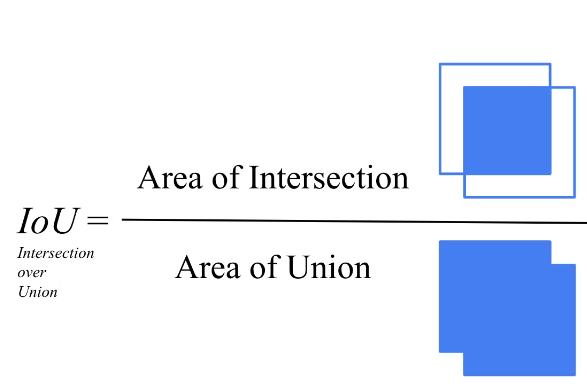

In [23]:
!python evaluate.py csv ../../annotations/test.txt ../../annotations/classes_mapping.txt ./snapshots/resnet152_csv.h5 --convert-model

2024-04-13 16:01:01.468473: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-13 16:01:01.468522: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-13 16:01:01.469619: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-04-13 16:01:02.494293: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
Traceback (most recent call last):
  File "/content/drive/MyDrive/Colab/retinanet/keras_retinanet/bin/evaluate.py", line 29, in <module>
    from ..preprocessing.csv_generator import CSVGenerator
  File "/content/drive/MyDrive/Colab/retinane

In [24]:
pwd

'/content/drive/MyDrive/Colab/retinanet/keras_retinanet/bin'

# 훈련 결과 확인하기(2. 박스 좌표 추출 후 이미지에 적용하여 확인하기)
학습된 모델이 Ground Truth와 비교하였을 때 잘 검출하였는지 이미지에 적용하여 눈으로 확인하는 부분입니다.



In [25]:
def resize_image(img, min_side=200, max_side=250):
    """ Resize an image such that the size is constrained to min_side and max_side.

    Args
        min_side: The image's min side will be equal to min_side after resizing.
        max_side: If after resizing the image's max side is above max_side, resize until the max side is equal to max_side.

    Returns
        A resized image.
    """
    # compute scale to resize the image
    scale = compute_resize_scale(img.shape, min_side=min_side, max_side=max_side)

    # resize the image with the computed scale
    img = cv2.resize(img, None, fx=scale, fy=scale)

    return img, scale

In [26]:
def compute_resize_scale(image_shape, min_side=200, max_side=250):
    """ Compute an image scale such that the image size is constrained to min_side and max_side.

    Args
        min_side: The image's min side will be equal to min_side after resizing.
        max_side: If after resizing the image's max side is above max_side, resize until the max side is equal to max_side.

    Returns
        A resizing scale.
    """
    (rows, cols, _) = image_shape

    smallest_side = min(rows, cols)

    # rescale the image so the smallest side is min_side
    scale = min_side / smallest_side

    # check if the largest side is now greater than max_side, which can happen
    # when images have a large aspect ratio
    largest_side = max(rows, cols)
    if largest_side * scale > max_side:
        scale = max_side / largest_side

    return scale

In [27]:
def read_image_bgr(path):
    """ Read an image in BGR format.

    Args
        path: Path to the image.
    """
    # We deliberately don't use cv2.imread here, since it gives no feedback on errors while reading the image.
    image = np.asarray(Image.open(path).convert('RGB'))
    return image[:, :, ::-1].copy()

학습을 했을 때 변경했던 영상으 크기를 동일하게 적용합니다.

In [28]:
image_min = 540
image_max = 960

학습된 모델을 로드합니다.

In [29]:
model = load_model('./snapshots/resnet152_csv.h5', backbone_name='resnet152')

OSError: No file or directory found at ./snapshots/resnet152_csv.h5

In [ ]:
model = models.convert_model(model)

test.txt 파일을 로드하여 파일들의 경로와 좌표를 가져옵니다.

In [ ]:

for i in range(len(txt_list)):
  with open('../../annotations/test.txt', mode="r") as file:
      content = list()
      while True:
          sentence = file.readline()

          if sentence:
              content.append(sentence)
          else:
              break


In [ ]:
content

In [ ]:
len(content)

In [ ]:
red = (0,0,255)

모델 예측 결과 이미지를 생성하기 전에 기존에 result_image에 존재하는 영상들이 존재한다면 제거해줍니다.

In [ ]:
data_list = glob.glob('../../result_image/*.jpg')
if len(data_list)!= 0:
  for data in data_list:
    os.remove(data)

In [ ]:
pwd

평가용 데이터를 로드하여 모델을 이용하여 예측을 한 후 x1,y1,x2,y2 각각 순차적으로 rectangle 메소드를 통해 영상에 적용합니다.

In [ ]:
for i in range(len(content)):

  image_name = content[i].split(',')[0].split('/')[-1]
  print(image_name)
  iii = read_image_bgr('../../../data/sample_img_eye/check_data/'+image_name)

  image, scale = resize_image(iii,image_min,image_max)
  boxes, scores, labels = model.predict_on_batch(np.expand_dims(image, axis=0))
  rr_img=image


  max_num = 0
  max_pred = 0.0
  num = 0
  for box, score, label_in in zip(boxes[0], scores[0],labels[0]):
      if score < 0.05:
          break


      if max_pred<scores[0][i]:
          #print(scores[0][i], ",", i)
          max_pred = scores[num][i]
          max_num = num
      num+=1

  #print(max_pred )
  x1 = boxes[0][max_num][0].astype(int)
  y1 = boxes[0][max_num][1].astype(int)
  x2 = boxes[0][max_num][2].astype(int)
  y2 = boxes[0][max_num][3].astype(int)
  img_check = cv2.rectangle(rr_img, (int(x1),int(y1)), (int(x2),int(y2)),red,3)
  cv2.imwrite('../../result_image/'+image_name.split('/')[-1].split('.')[0]+".jpg",img_check)



In [ ]:
pre_list = glob.glob('../../result_image/*.jpg')

In [ ]:
pre_list.sort()

# 결과 확인하기
파랑색으로 생성된 박스는 Ground Truth이며, 빨간색 선이 모델이 예측한 결과입니다.

In [ ]:
i = 0
pre_img = cv2.imread(pre_list[i])
#after_img = cv2.imread(after_list[i])
pre_cvt = cv2.cvtColor(pre_img,cv2.COLOR_BGR2RGB)
#after_img = cv2.cvtColor(after_img,cv2.COLOR_BGR2RGB)

plt.figure(figsize=(20, 20))
plt.subplot(1,1,1)
plt.imshow(pre_cvt)
plt.axis('off')


In [ ]:
i = 17
pre_img = cv2.imread(pre_list[i])
pre_cvt = cv2.cvtColor(pre_img,cv2.COLOR_BGR2RGB)

plt.figure(figsize=(20, 20))
plt.subplot(1,1,1)
plt.imshow(pre_cvt)
plt.axis('off')
